# Week 10 (Module 21) - BBO capstone driver

Round 10. Three rounds left after this one (W11, W12 dress rehearsal, then final locks). Every query serves the endgame: verify what's banked, chase live signal, hold the rest steady.

**Plan:**
- **f1 -> perpendicular probe (0.385, 0.511)**: the three readings so far bracket the hot spot along one line (strongest at (0.41, 0.47)); this closes in from the other axis.
- **f2 -> tight refine** near the new 0.682 winner (first improvement in nine weeks - is there more?).
- **f3 -> AEI conservative**.
- **f4 -> EXACT RE-SUBMIT of the W2 winner (repro test)**: +/-0.01 cost 0.23 last week while +/-0.02 cost only 0.03 the week before - loss doesn't track distance, so either razor-rugged or noisy. If 0.5401 doesn't reproduce, the banked value was partly luck and we need the remaining weeks to react.
- **f5 -> space_fill** (peak banked; exploration free).
- **f6 -> tiny step, fresh direction** (basin is locally flat - map its edge).
- **f7 -> tiny step, fresh direction** (W9's direction sloped down; try another).
- **f8 -> MES** (three consecutive marginal nudges - keep collecting).


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 10
SEED = 10
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: perpendicular probe from the strongest reading.
f1_x = np.array([0.385000, 0.511000])
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="llm_probe", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0, n_data=len(bo.load(1)[1]))

# f4: exact re-submit of the W2 winner - reproduction test.
f4_x = np.array([0.409370, 0.417326, 0.352834, 0.435452])
m4 = bo.fit(4)
results[4] = dict(x=f4_x, u=bo.to_unit(f4_x.reshape(1,-1), m4.b).reshape(-1),
                  submission=bo.format_submission(f4_x), acq="repro_test",
                  mean=float('nan'), std=float('nan'), incumbent_y=0.5401,
                  n_data=len(bo.load(4)[1]), model=m4)

def tight_refine(fid, scale, clamp=None):
    X, y, d = bo.load(fid); b = bo.bounds(fid, d)
    x_best = X[int(np.argmax(y))]
    pert = rng.normal(0, scale, size=d)
    if clamp: pert = np.clip(pert, -clamp, clamp)
    x_new = np.clip(x_best + pert, 0.0, 0.999999)
    m = bo.fit(fid)
    mean, std = m.predict(bo.to_unit(x_new.reshape(1,-1), b))
    return dict(x=x_new, u=bo.to_unit(x_new.reshape(1,-1), b).reshape(-1),
               submission=bo.format_submission(x_new), acq="tight_refine",
               mean=float(mean[0]), std=float(std[0]), incumbent_y=float(y.max()),
               n_data=len(y), model=m)

results[2] = tight_refine(2, scale=0.02)
results[6] = tight_refine(6, scale=0.015)
results[7] = tight_refine(7, scale=0.015)

GP_PLAN = {3: dict(acq="aei", xi=0.10), 5: dict(acq="space_fill"), 8: dict(acq="mes")}
for fid, plan in GP_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)

for fid in bo.FUNC_IDS:
    bo.validate_submission(results[fid]["submission"], len(results[fid]["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,source,incumbent,submission
0,f1,llm_probe,0.0000,0.385000-0.511000
1,f2,tight_refine,0.6823,0.677784-0.032638
2,f3,aei,-0.0348,0.999999-0.000000-0.837472
3,f4,repro_test,0.5401,0.409370-0.417326-0.352834-0.435452
4,f5,space_fill,8662.4050,0.993054-0.999353-0.238204-0.314632
5,f6,tight_refine,-0.2545,0.467354-0.370385-0.594264-0.730043-0.012646
6,f7,tight_refine,1.8390,0.012869-0.128449-0.034270-0.159948-0.320000-0...
7,f8,mes,9.9499,0.121740-0.148809-0.117860-0.213150-0.999999-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,19,0.0000,NaN,NaN,llm_probe,0.385000-0.511000
1,f2,2,19,0.6823,0.4885,0.0238,tight_refine,0.677784-0.032638
2,f3,3,24,-0.0348,0.0301,0.0552,aei,0.999999-0.000000-0.837472
3,f4,4,39,0.5401,NaN,NaN,repro_test,0.409370-0.417326-0.352834-0.435452
4,f5,4,29,8662.4050,249.2150,838.5544,space_fill,0.993054-0.999353-0.238204-0.314632
5,f6,5,29,-0.2545,-0.2594,0.0041,tight_refine,0.467354-0.370385-0.594264-0.730043-0.012646
6,f7,6,39,1.8390,1.7414,0.0669,tight_refine,0.012869-0.128449-0.034270-0.159948-0.320000-0...
7,f8,8,49,9.9499,9.9500,0.0013,mes,0.121740-0.148809-0.117860-0.213150-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r.get("model") or bo.fit(fid)
        r["model"] = m
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, np.atleast_2d(r["u"])).items()}
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,0.0020,0.0000,0.0000
1,f2,0.0000,0.5361,0.0000,0.0006
2,f3,0.0088,0.1406,0.2627,0.0031
3,f4,0.0131,0.7202,0.1386,0.0347
4,f5,0.0000,1926.3237,0.0000,703173.4033
5,f6,0.0000,-0.2512,0.0001,0.0000
6,f7,0.0015,1.8752,0.0539,0.0045
7,f8,0.0000,9.9525,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

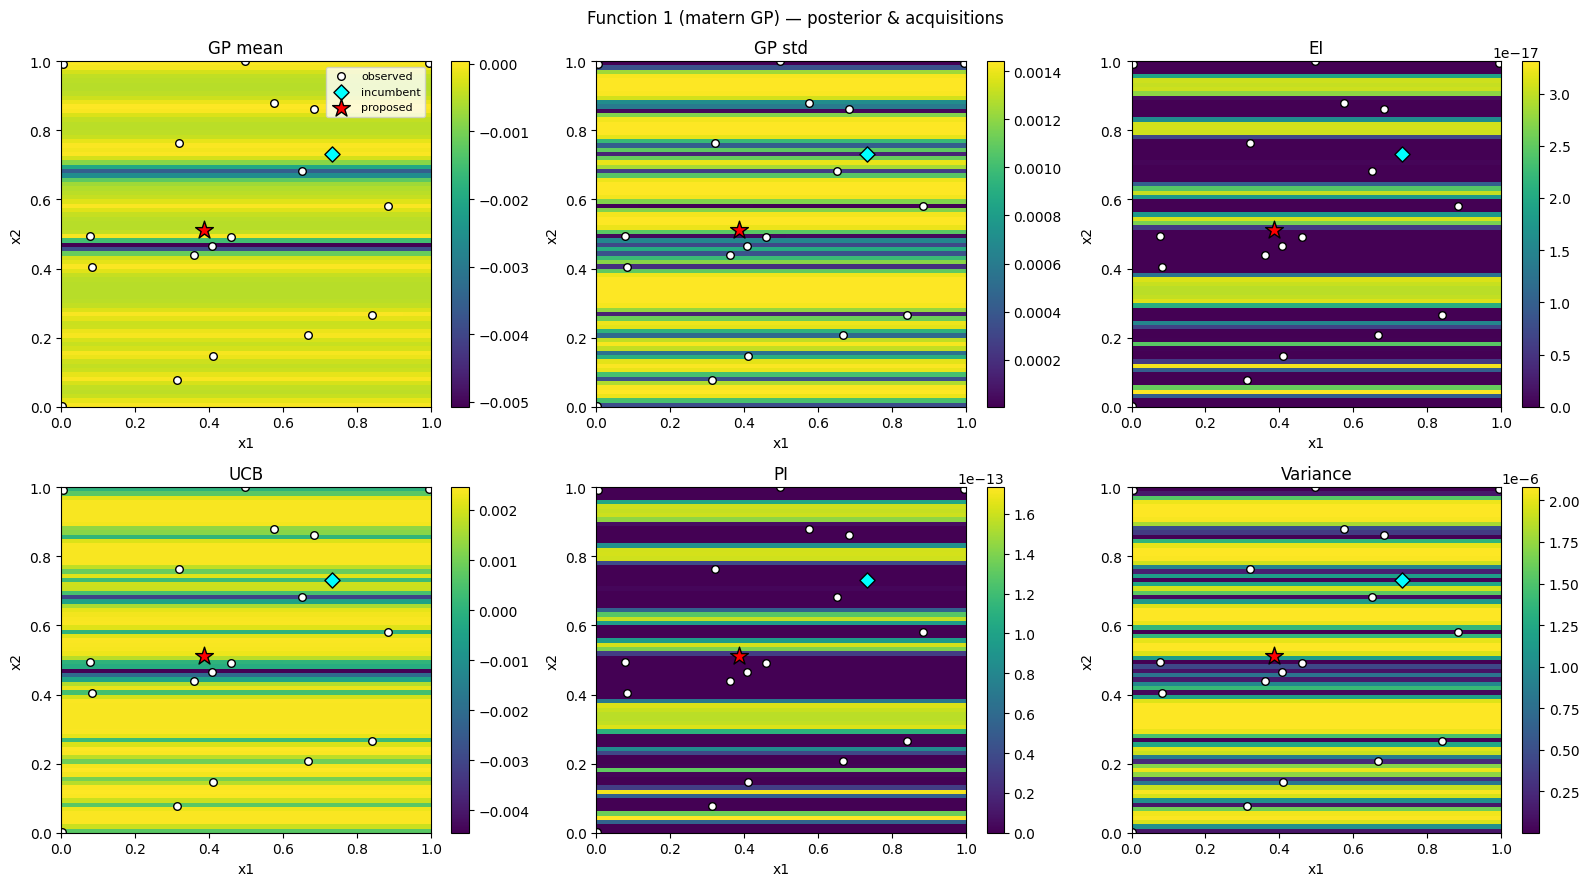

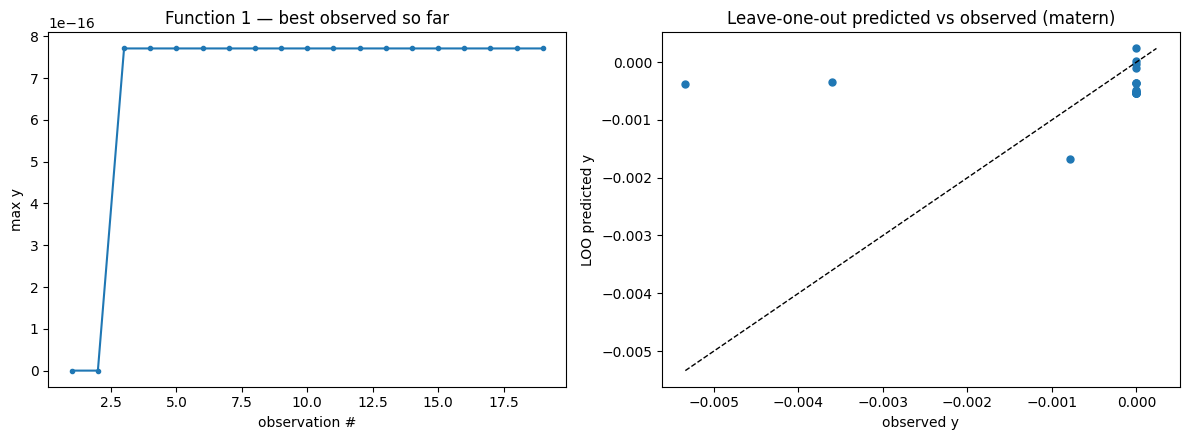

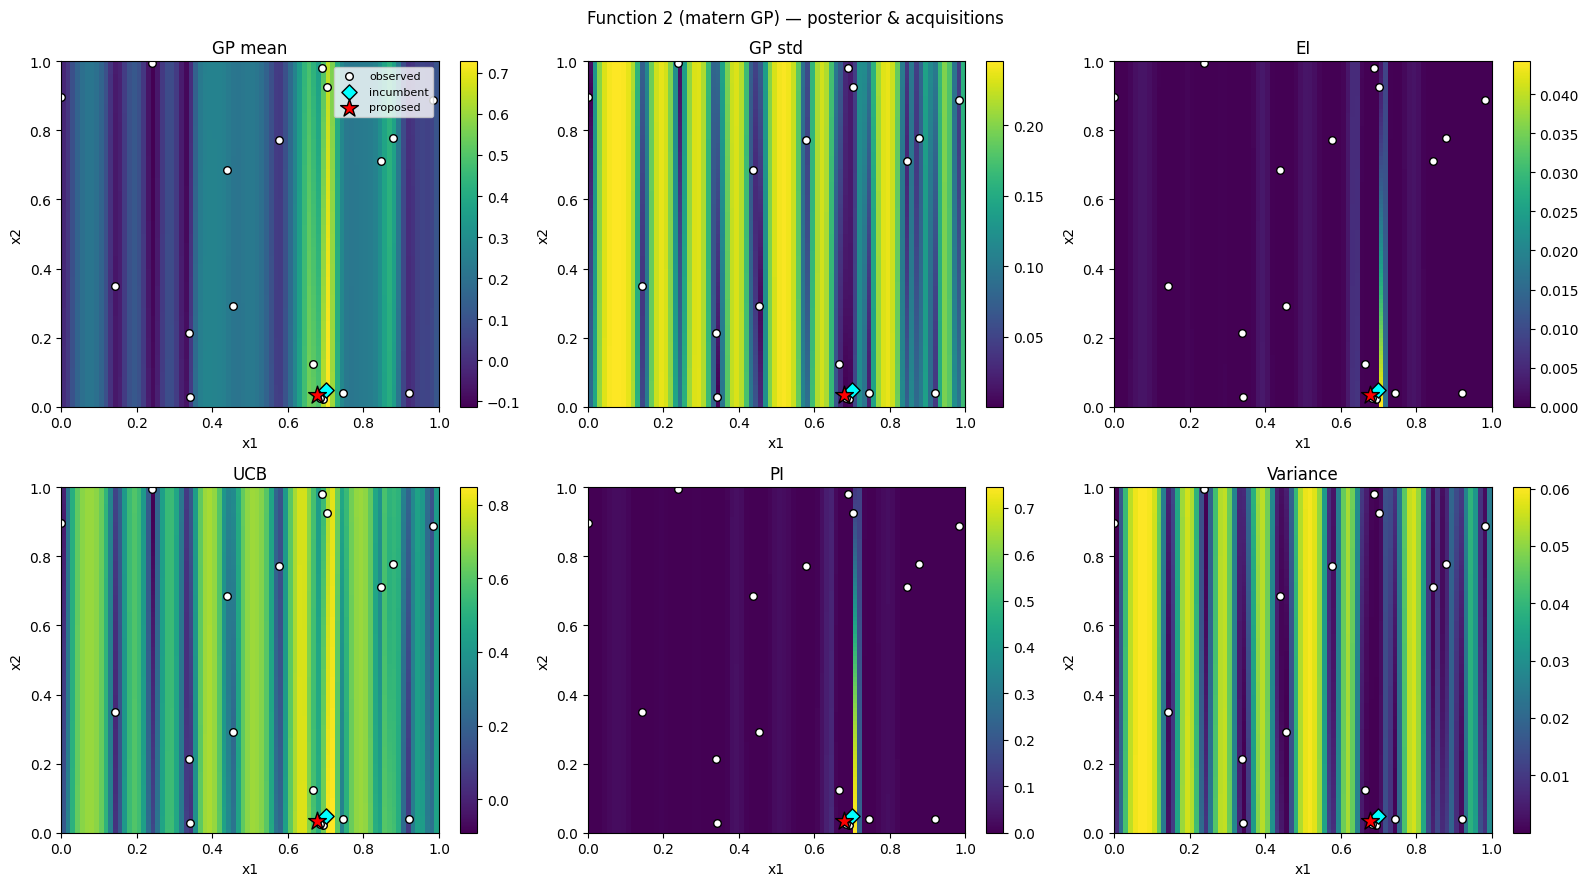

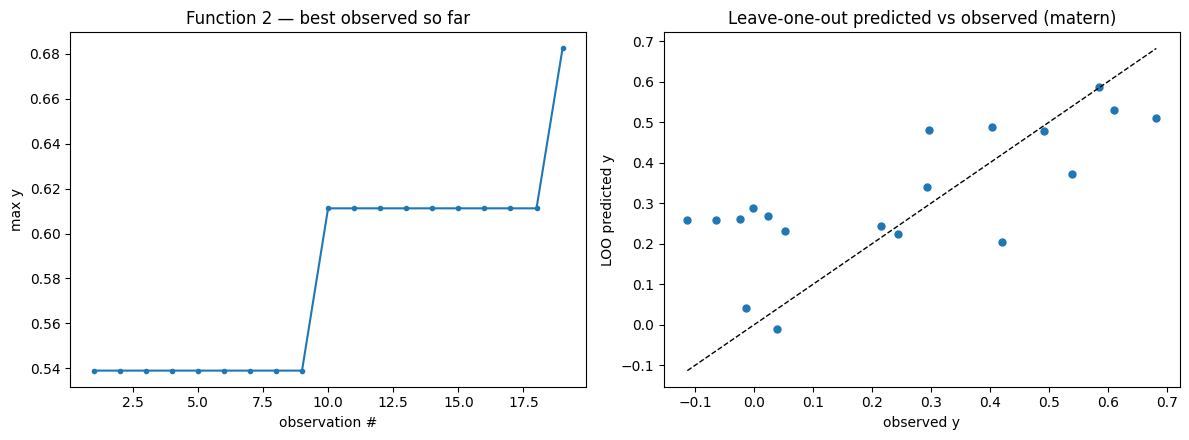

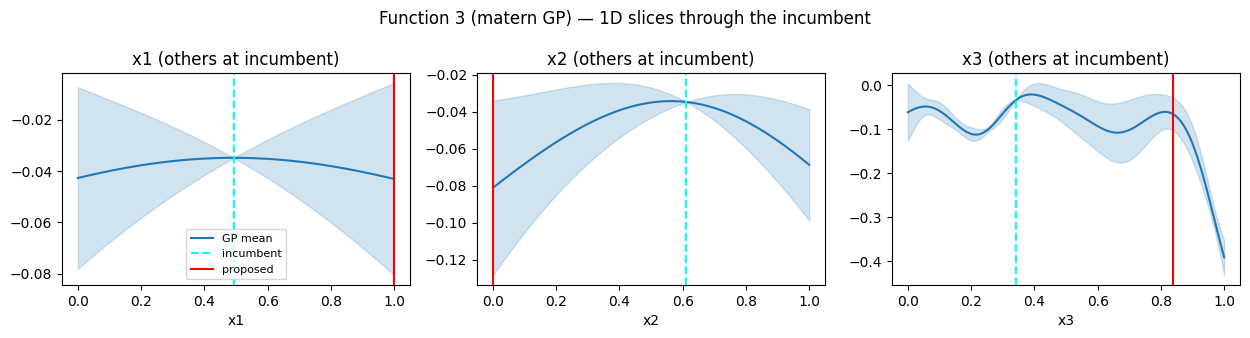

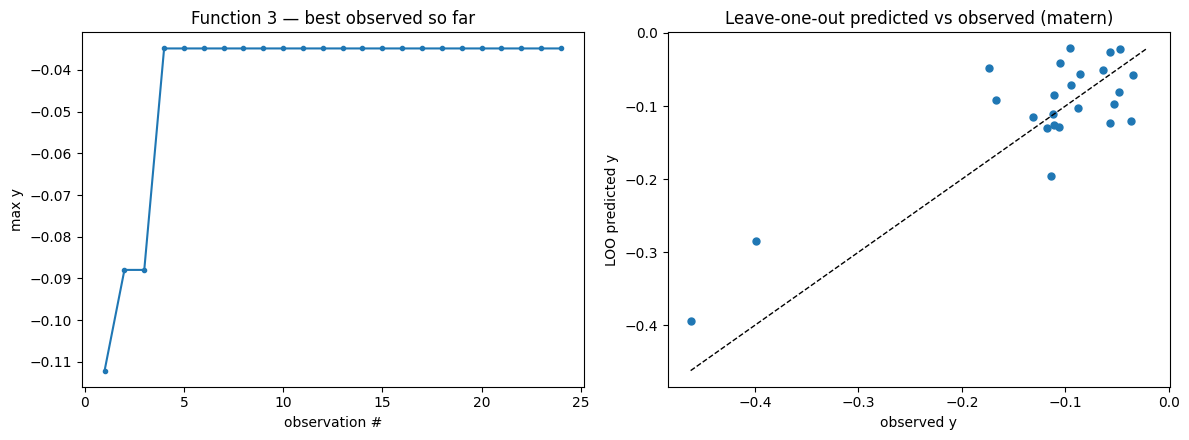

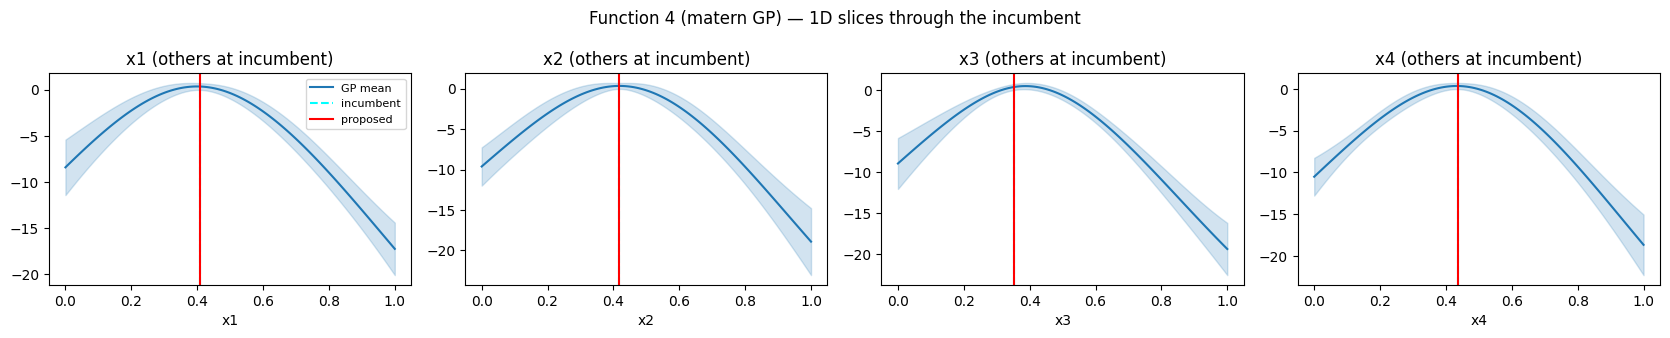

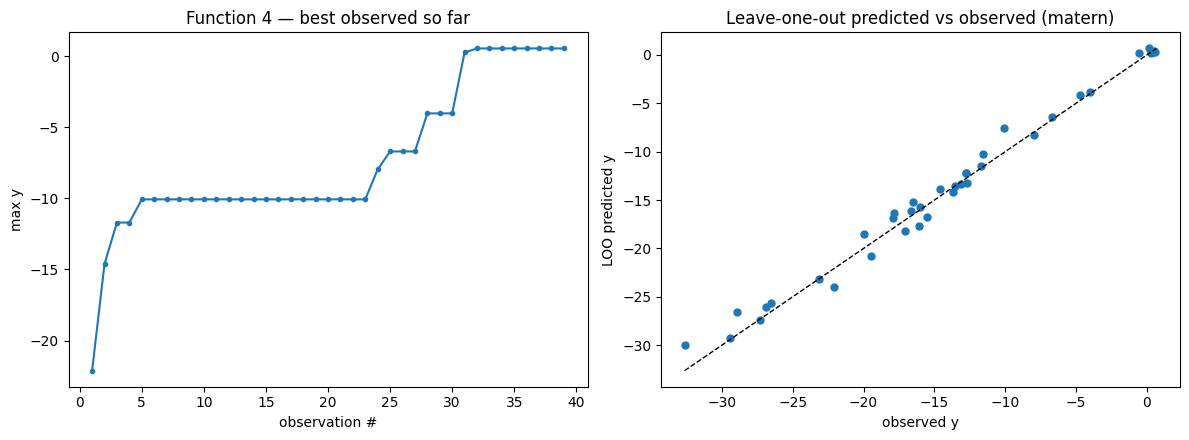

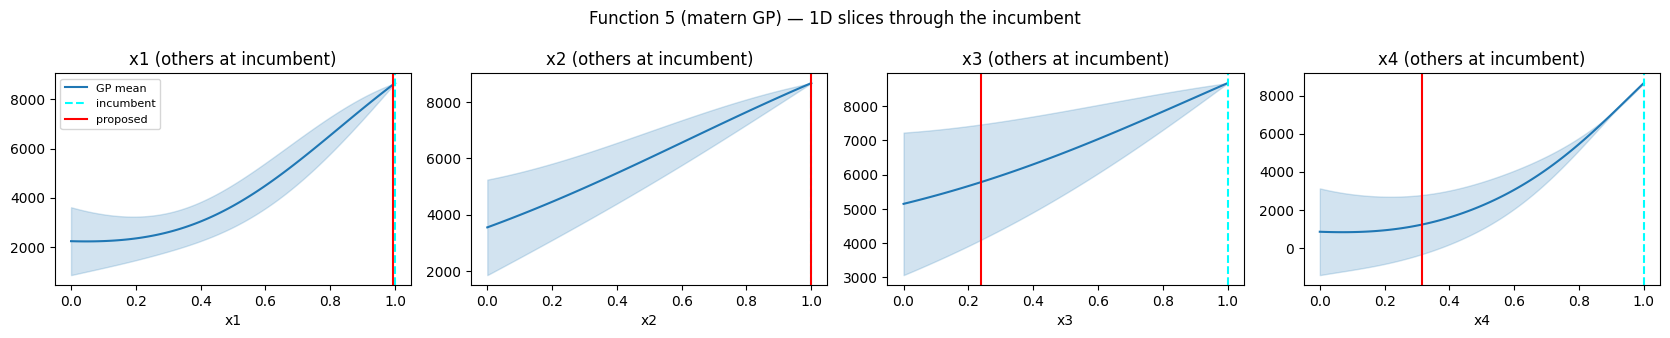

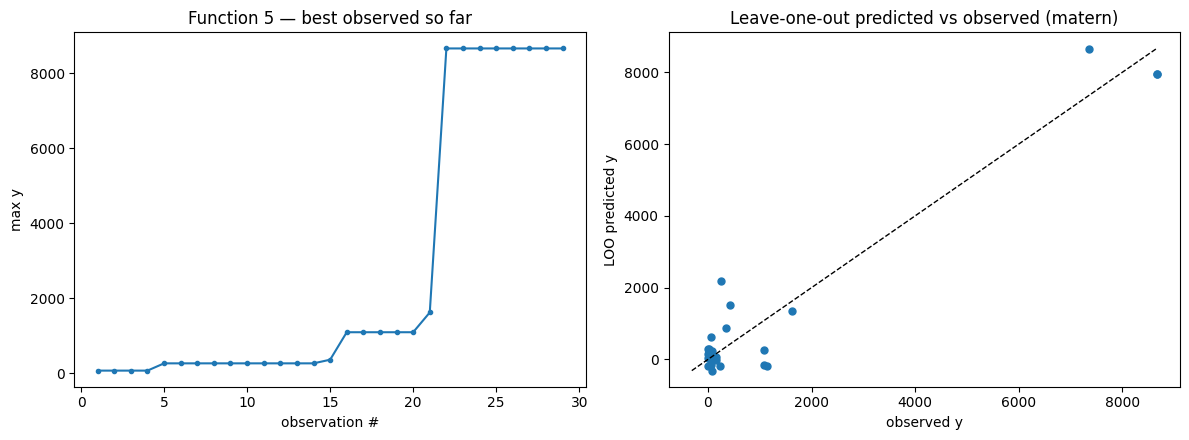

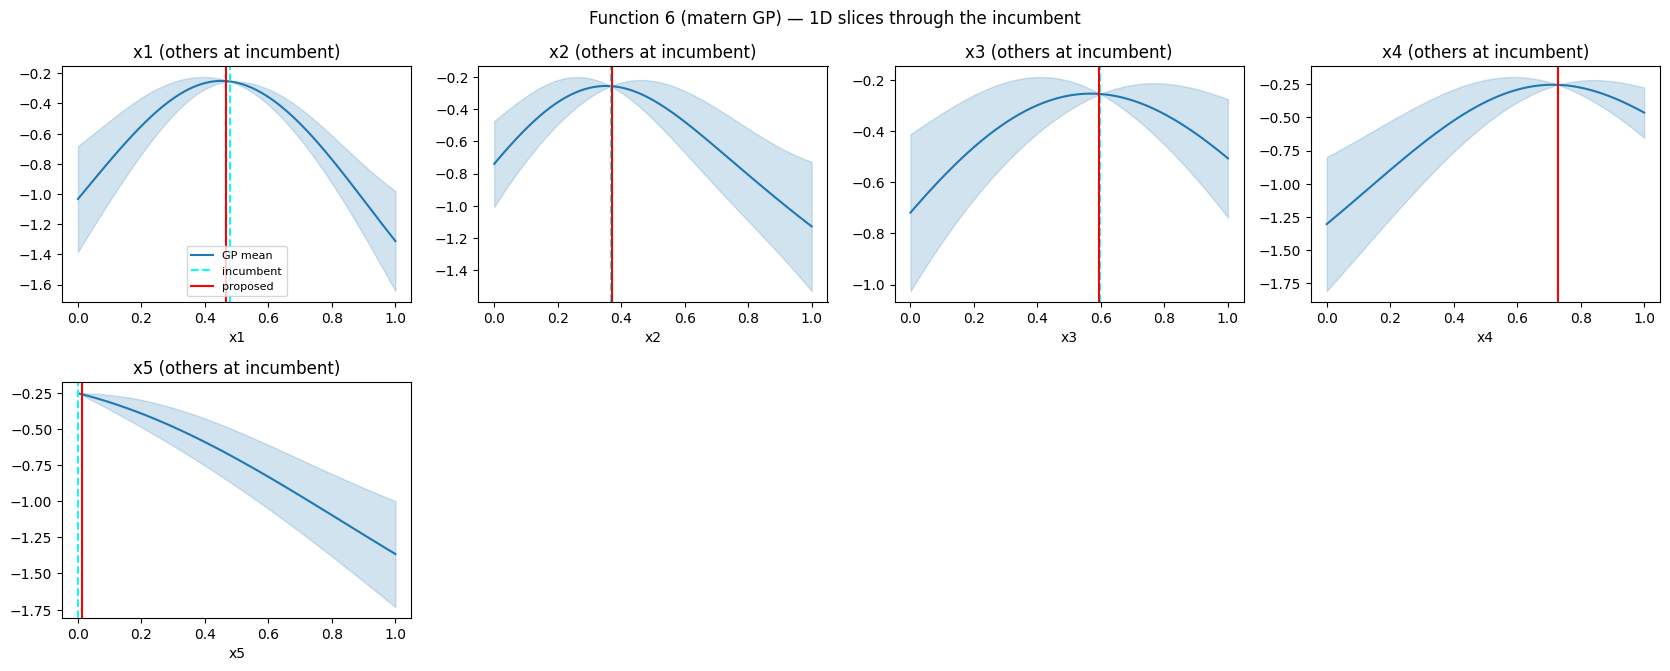

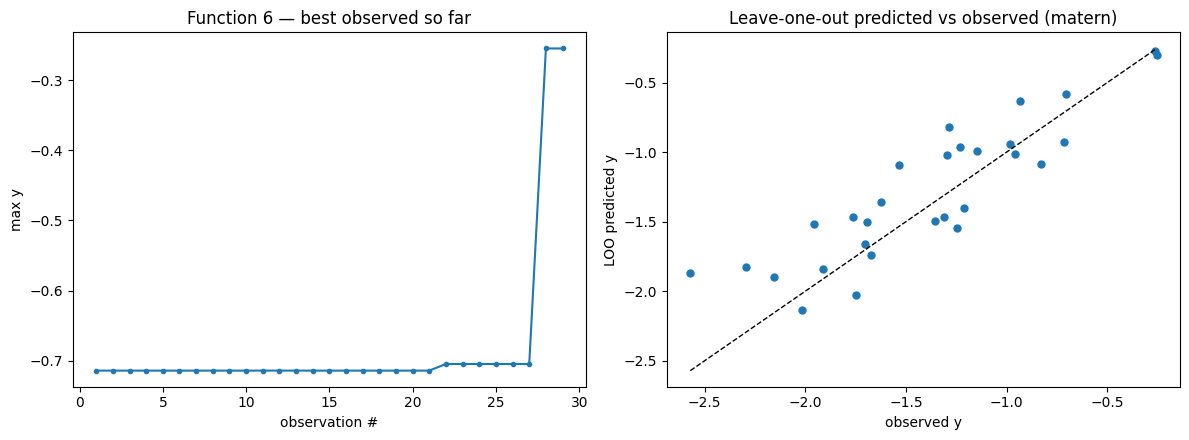

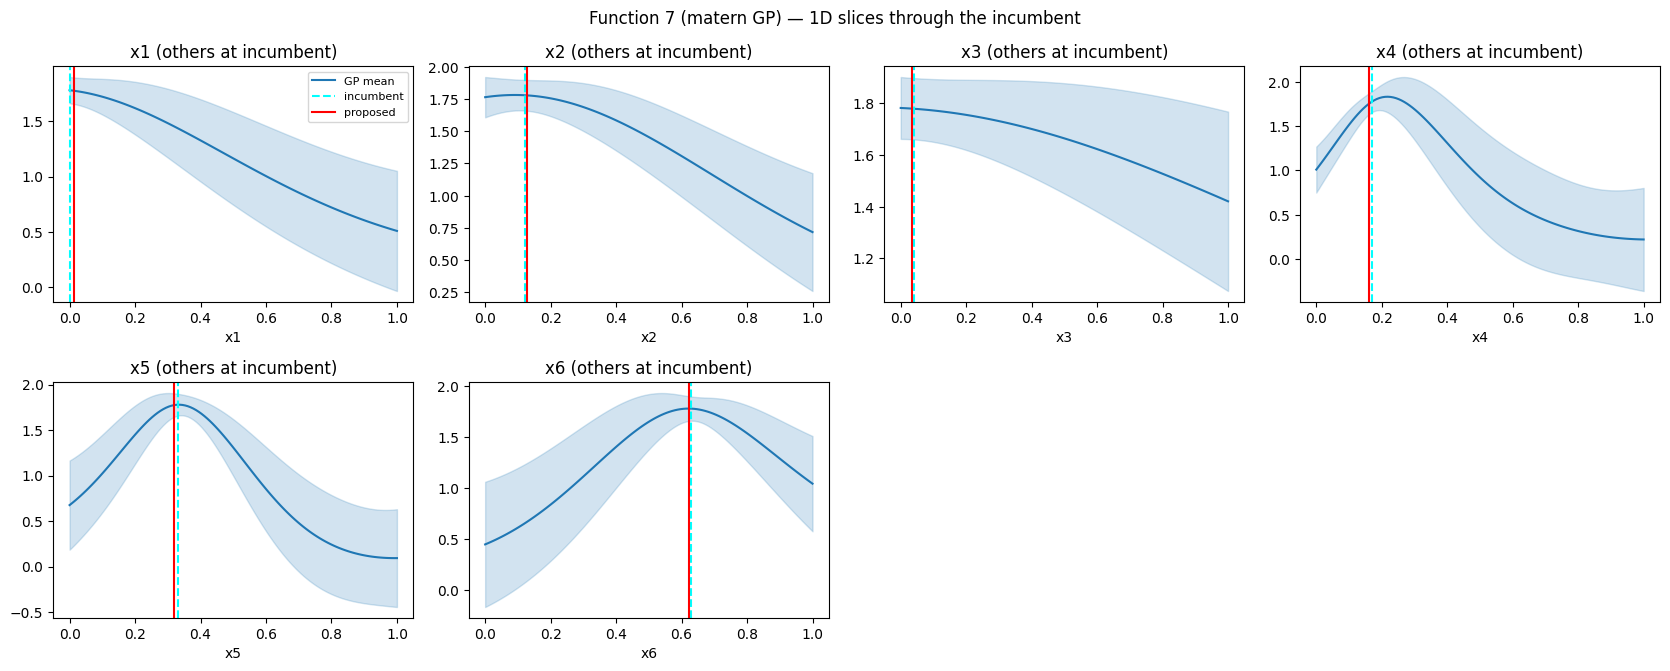

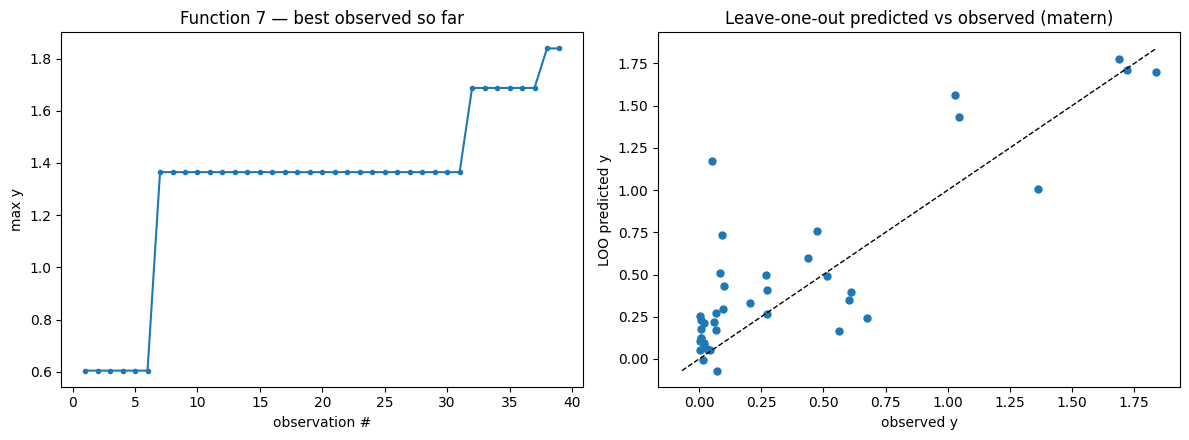

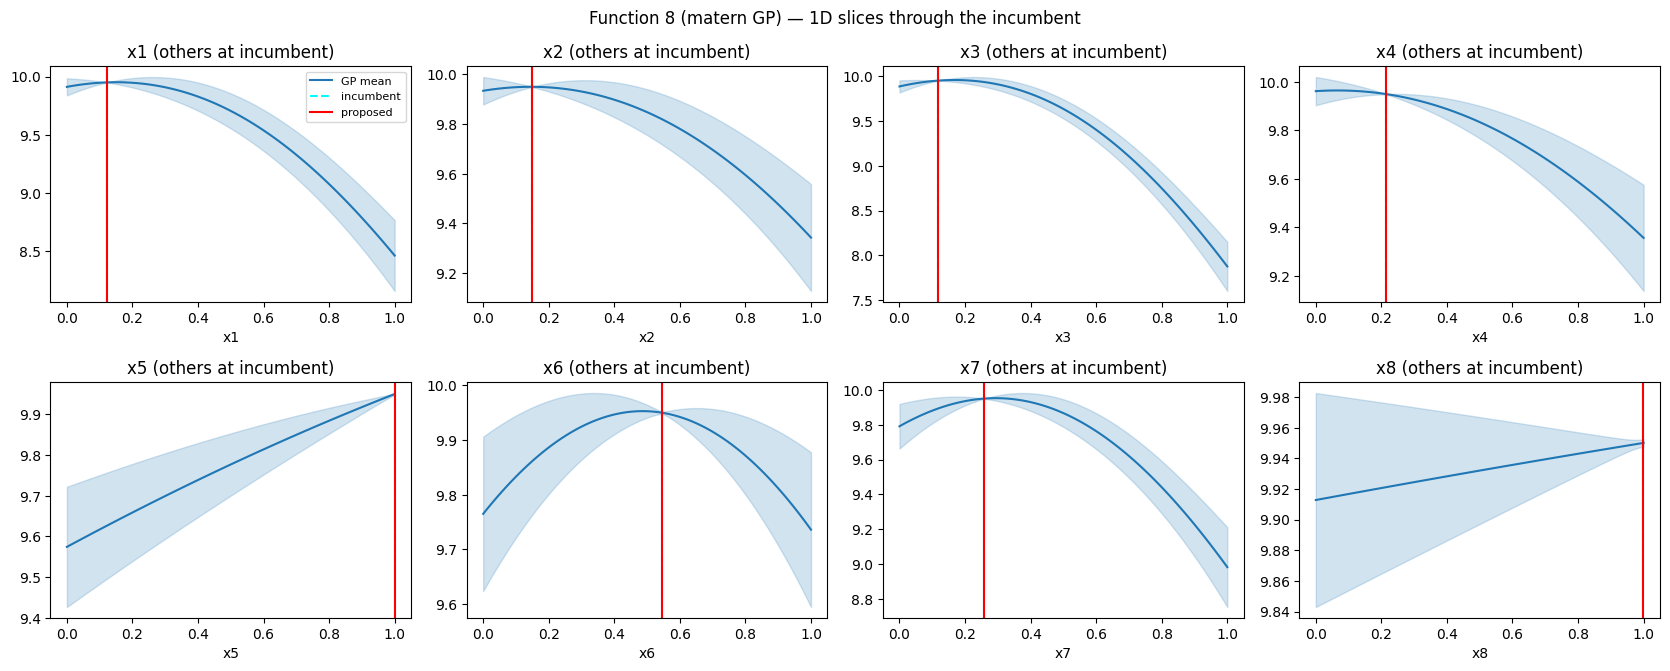

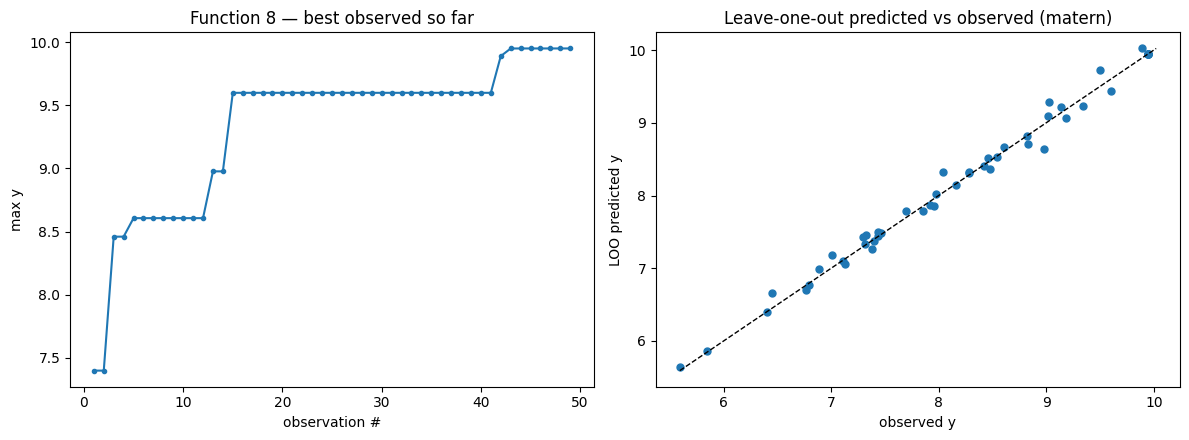

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r.get("model") or bo.fit(fid)
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.385000-0.511000
f2:  0.677784-0.032638
f3:  0.999999-0.000000-0.837472
f4:  0.409370-0.417326-0.352834-0.435452
f5:  0.993054-0.999353-0.238204-0.314632
f6:  0.467354-0.370385-0.594264-0.730043-0.012646
f7:  0.012869-0.128449-0.034270-0.159948-0.320000-0.623556
f8:  0.121740-0.148809-0.117860-0.213150-0.999999-0.545160-0.258462-0.997744


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite an already-written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week10.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 10 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: -3.2476529132156495e-08,
#     2: 0.5463410285405027,
#     3: -0.10036144044464712,
#     4: 0.5401292083386946,
#     5: 1585.9300081817114,
#     6: -0.26287727535167116,
#     7: 1.81901809674012,
#     8: 9.9499283995769,
# }
#
# HEADLINE: f4 REPRODUCTION TEST PASSED.
#   W2 return:  0.5401292083386875
#   W10 return: 0.5401292083386946  (identical to 12 decimal places; difference is float jitter)
#   Combined with f5's W3 reproduction (15 decimals), that's 2-for-2: the portal functions
#   are DETERMINISTIC. Every banked best is safely lockable by exact re-submission.
#   W9's +/-0.01 -> 0.309 was RUGGEDNESS, not noise: the 0.540 peak is real and razor-thin.
#
# Also this round:
#   f8 9.9499284  NEW BEST (marginal) - 4th consecutive MES nudge.
#   f1 -3.2e-8 at (0.385, 0.511): perpendicular probe found nothing. Hot spot is TIGHT
#      around (0.41, 0.47) - readings die off within ~0.05 in every direction tried.
#   f2 0.546 (refine near 0.682 winner came back lower - rugged, winner stands)
#   f3 -0.100 (miss)   f5 1586 (another region mapped)
#   f6 -0.263, f7 1.819 (both close to winners; winners stand)
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
